# COMP8325 Week 4 Workshop
# Unsupervised Learning: Clustering
* ### Demos for clustering models
* ### Task 1 Perform K-means on a real dataset
* ### Task 2 Perform agglomerative clustering on this data set
* ### Task 3 (Optional) Try PCA for dimensionality reduction.


In [1]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score

from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from scipy.spatial.distance import pdist 

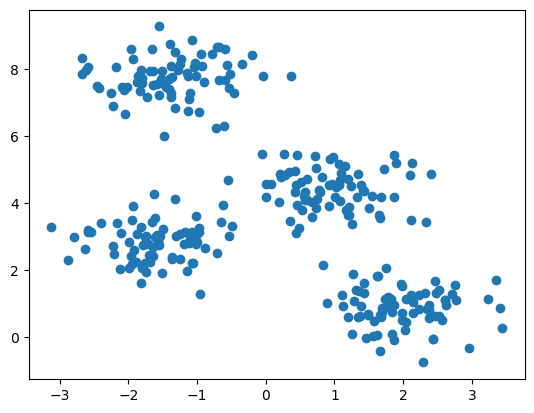

In [113]:
# Generate an example 2-dimensional dataset containing 4 clusters for a demo
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Visualize the data
plt.scatter(X[:,0], X[:,1])
plt.show()

### Demo for K-means clustering

In [115]:
# Create a K-means clustering model with k=4, and k-means++ as the intialization strategy
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=0)

# Perform clustering by fitting the model with the data
kmeans.fit(X)

# We can explore the parameters learned from the data. 
# What's the cluster center? 
print('\n Cluter center: \n', kmeans.cluster_centers_)


 Cluter center: 
 [[ 0.94973532  4.41906906]
 [ 1.98258281  0.86771314]
 [-1.37324398  7.75368871]
 [-1.58438467  2.83081263]]


Recall from the lecture that the K-Means algorithm tries to minimise the objective function:
$$
J = \sum_{n = 1}^N \sum_{k = 1}^K r_{n, k} \lVert \mathbf{x}_n - \boldsymbol{\mu}_{k} \rVert^2
$$
In `sklearn` the value of $J$ can be obtained via the `inertia_` attribute. We can obtain both $J$ and its average across all points. We will call this ***distortion***.


In [117]:
# What's is overall distorion (inertia)? 
print('\n Overall distortion: \n', kmeans.inertia_)
# Average standard distortion (inertia)
print('\n Average distortion: \n', math.sqrt(kmeans.inertia_/X.shape[0]))


 Overall distortion: 
 212.00599621083478

 Average distortion: 
 0.8406465690384491


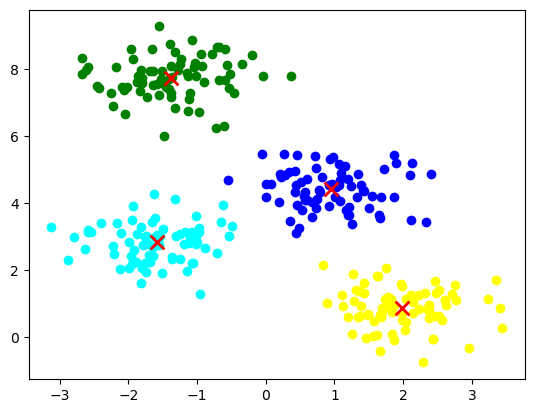

In [119]:
# Predict the cluster for each data instance. This step can be combined with the last one by using kmeans.fit_predict(X)
y_pred = kmeans.predict(X)

# Visualize the cluster centers to explore how the clustering result looks like
colors = ['blue', 'yellow', 'green', 'cyan']
for i, color in enumerate(colors):
    plt.scatter(X[y_pred == i, 0], X[y_pred == i, 1], c=color)
     
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', lw=2, c='red', s=100)
plt.show()

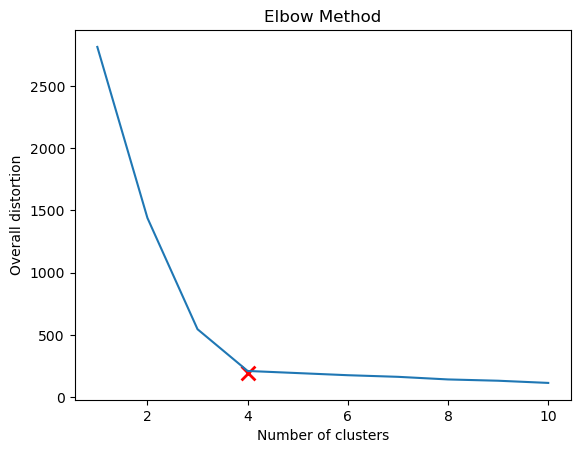

In [20]:
# How about other k values? Which k value should we choose to get the optimal clustering? Let's vary k from 1 to 10 and see how the distortion changes.
distortions = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=0)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)
    
# Plot the relationship between the distortion and k. Then, we can have the Elbow method to help identify a good value for k.
plt.plot(range(1, 11), distortions)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Overall distortion')
plt.scatter(4, distortions[4], marker='x', lw=2, c='red', s=100)
plt.show()

# It can be seen that k=4 is reasonably good

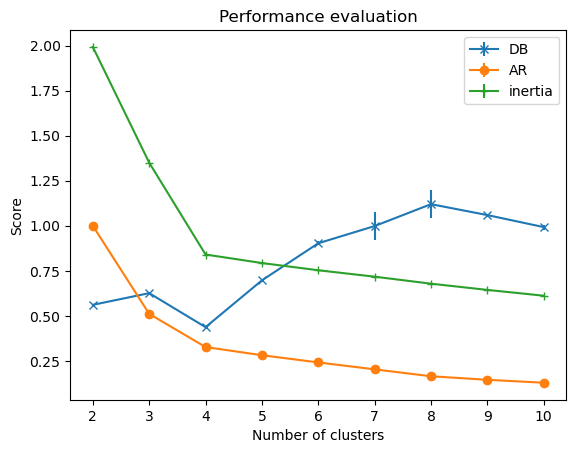

In [28]:
# Let's evaluate the learned model with other quality criteria

# Internal evaluation, davies bouldin score (the lower, the better)
db_scores = []
db_scores_std = []

# External evaluation, adjusted rand index (the higher, the better)
ar_scores = []
ar_scores_std = []

# Inertia (average standardized)
inertia = []
inertia_std = []

for i in range(2, 11):
    # Multiple runs for stable indicators
    db_scores_tmp = []
    ar_scores_tmp = []
    inertias_tmp = []
    
    n_iteration=5
    for j in range(0, n_iteration):
        # Note: 'random_state' parameter should be set as default or None
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10)
        #kmeans = KMeans(n_clusters=i, init='random', max_iter=300)
        kmeans.fit(X)
        labels = kmeans.labels_
        db_scores_tmp.append(davies_bouldin_score(X, labels))
        ar_scores_tmp.append(adjusted_rand_score(labels, y_pred))
        inertias_tmp.append(math.sqrt(kmeans.inertia_/X.shape[0]))
    
    db_scores.append(np.mean(db_scores_tmp))
    db_scores_std.append(np.std(db_scores_tmp))
    ar_scores.append(np.mean(ar_scores_tmp))
    ar_scores_std.append(np.std(ar_scores_tmp))
    inertia.append(np.mean(inertias_tmp))
    inertia_std.append(np.std(inertias_tmp))

# Plot the relationship between the davies bouldin score and k
plt.errorbar(range(2, 11), db_scores, yerr=db_scores_std, marker='x', label='DB')
plt.errorbar(range(2, 11), ar_scores, yerr=ar_scores_std, marker='o', label='AR')
plt.errorbar(range(2, 11), inertia, yerr=inertia_std, marker='+', label='inertia')
plt.title('Performance evaluation')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.legend(loc='best')
plt.show()

### Demo for agglomerative clustering

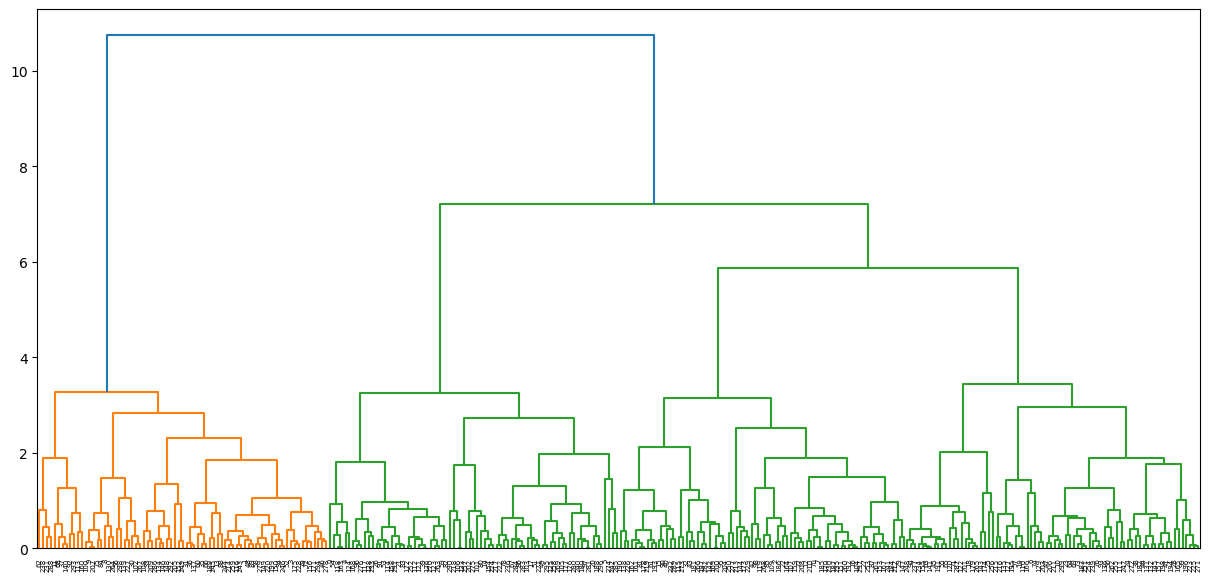

In [31]:
# Try agglomerative clustering on this dataset, and visualise the hierarchy.

dist = pdist(X, 'euclidean')
linkage_matrix = linkage(dist, method = 'complete')

plt.figure(figsize=(15,7))
dendrogram(linkage_matrix)
plt.show()

# It can be seen that the clustering structure contains four main clusters, complying with the data.

### Demo of Clustering on a real data set - MNIST
Now, let's work on a real dataset. See detailed information for the dataset: https://en.wikipedia.org/wiki/MNIST_database. Each sample is a $28 \times 28 = 784$ image, thus having 784 pixels each. This is represented as a 784 dimensional array. The value for each pixel is the grayscale value (from 0 to 255). 

In [3]:
#Load the data. Orignal data set has been processed (downsampled) to facilitate your data analysis
raw_data = pd.read_csv("C:\\Users\\Hitomi\\OneDrive\\Desktop\\[Neo]COMP8325 Applications of Artificial Intelligence for Cyber Security\\Week 4_Material\\mnist-0.1.csv")
print('\n data size: (%d, %d)\n' % raw_data.shape)

# Specifying features and target attribute
X = raw_data.drop(['Label'], axis='columns')

# Pre-processing with standardization
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler()
X_data = X.values
X_scaled = scaler.fit_transform(X_data)
X = X_scaled

y = raw_data['Label'].values
print("Unique labels in raw data:", np.unique(y))


 data size: (5243, 785)

Unique labels in raw data: [-1  1]


In [99]:
# K-means clustering model with 2 clusters are assumed.
model = KMeans(n_clusters=2)
model.fit(X)
print('\n cluster means: \n', model.cluster_centers_)
print('\n inertia: %f'% model.inertia_)
print('\n average inertia: %f\n' % math.sqrt(model.inertia_/y.size))


 cluster means: 
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

 inertia: 214711.095204

 average inertia: 6.399371



In [101]:
# Evaluation (internal)
labels = model.labels_
scores=davies_bouldin_score(X, labels)
print('\n davies_bouldin_score: %f\n' % scores)


 davies_bouldin_score: 2.728248



### Task 1 

For the above dataset, try k from 2 to 10 to determine which is the best value w.r.t. `davies_bouldin_score`. Plot the relationship between the `davies_bouldin_score` and k.


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=21.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, w

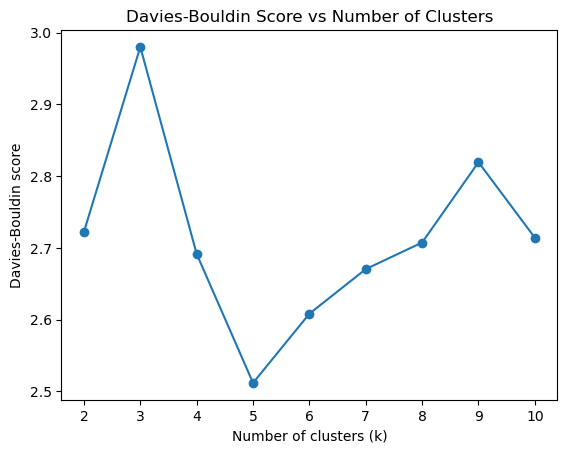

In [4]:
# Build the models
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt

db_scores = []

# try different k values
for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0)
    kmeans.fit(X)

    labels = kmeans.labels_

# Compute davies bouldin score
    db = davies_bouldin_score(X, labels)

    db_scores.append(db)

# Plot the relationship between the distortion and k
plt.plot(range(2,11), db_scores, marker='o')
plt.title("Davies-Bouldin Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score")
plt.show()

### Task 2 

Try to perform agglomerative clustering on the dataset, and visualise the hierarchy.

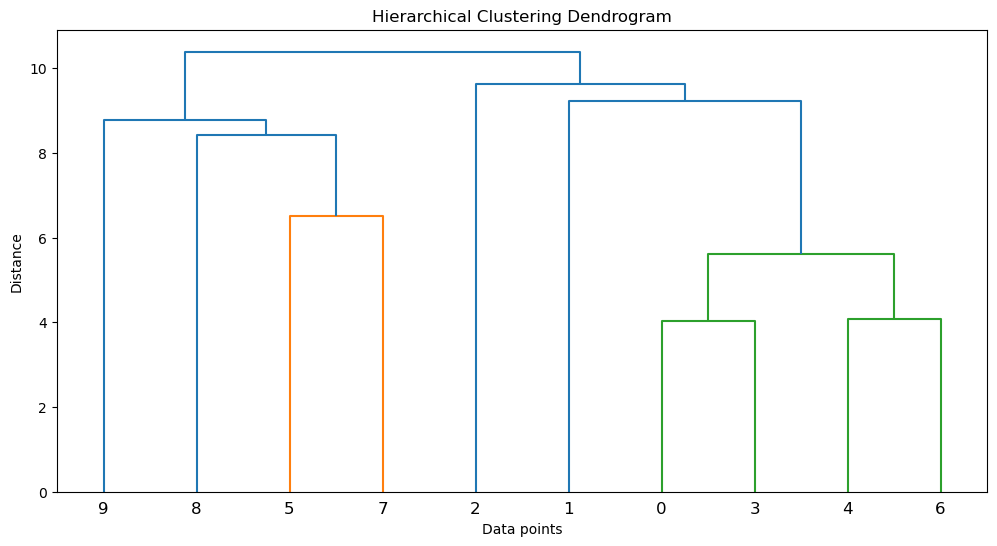

In [13]:
# Add your code here ...
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Use a smaller subset of the dataset
X_sample = X[:10]

# compute pairwise distances
dist = pdist(X_sample, 'euclidean')

# hierarchical clustering
linkage_matrix = linkage(dist, method='complete')

# plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

### Task 3 (Optional) 

Given that this is a high dimensional data. It might be good to reduce the dimension first. PCA can be used for this purpose. Try some reduced dimensionality, e.g., math.sqrt(X.shape[1]). Try this for different k values with plotting.

For a brief introduction to PCA see https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html. In particular you will need to specifiy the number of components in PCA as the square root of the original dimension as mentioned above by setting `n_components` to this value. You can then use the `.fit()` and `.transform()` methods to obtained a dimensionally reduced dataset.



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=21.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=21.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=21.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

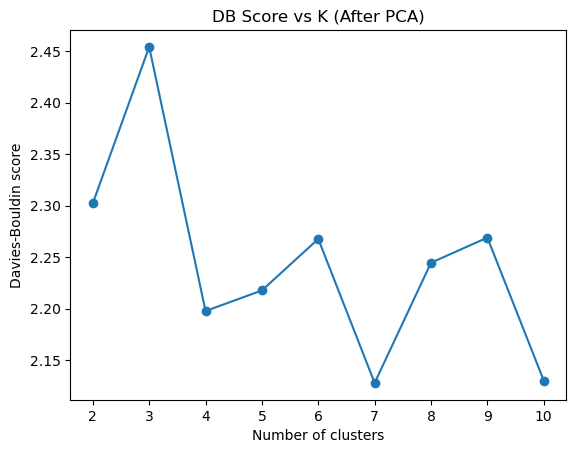

In [14]:
# Perform dimenion redcution
import math
from sklearn.decomposition import PCA

# Build clustering models
# dimension reduction
n_comp = int(math.sqrt(X.shape[1]))
pca = PCA(n_components=n_comp)
X_reduced = pca.fit_transform(X)

# Compute davies bouldin score
db_scores_pca = []

for k in range(2,11):

    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_reduced)

    labels = kmeans.labels_
    db = davies_bouldin_score(X_reduced, labels)
    db_scores_pca.append(db)
    
# Plot the relationship between the distortion and k
plt.plot(range(2,11), db_scores_pca, marker='o')
plt.title("DB Score vs K (After PCA)")
plt.xlabel("Number of clusters")
plt.ylabel("Davies-Bouldin score")
plt.show()